In [1]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
DATASET = "medsegbench"  # Options: "totalseg_ct", "totalseg_mri", "medsegbench"

# Filter options (applied before analysis)
EXCLUDE_VERTEBRAE = False  # Set to True to exclude vertebrae from analysis
EXCLUDE_RIBS = False       # Set to True to exclude ribs from analysis
EXCLUDE_CUSTOM = []        # Add custom label patterns to exclude, e.g. ['kidney_cyst']
EXCLUDE_RESOLUTIONS = [128]   # Resolutions to exclude, e.g. [128, 512] to keep only 256

dataset_configs = {
    "medsegbench": {"patch_icl": "l8huu3nw", "universeg": "gwyrmzg2"},
    "totalseg_mri": {"patch_icl": "it2791g9", "universeg": "heb3m2pl"},
    "totalseg_ct": {"patch_icl": "eqjm8p9c", "universeg": "w3vfqmn2"},
}

runs = {k: {"wandb_name": v} for k, v in dataset_configs[DATASET].items()}
print(f"Dataset: {DATASET}")
print(f"Filters: vertebrae={EXCLUDE_VERTEBRAE}, ribs={EXCLUDE_RIBS}, custom={EXCLUDE_CUSTOM}, resolutions={EXCLUDE_RESOLUTIONS}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/dpxuser/.netrc.
wandb: Currently logged in as: tidiane to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset: medsegbench
Filters: vertebrae=False, ribs=False, custom=[], resolutions=[128]


In [2]:
# Download artifacts and combine into single DataFrame
for run_name, run_data in runs.items():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run_data['wandb_name']}-per_case_dice:v0")
    artifact.download()
    table = artifact.get("per_case_dice.table.json")
    runs[run_name]["df"] = table.get_dataframe()

df_all = pd.concat([df.assign(Run=name) for name, data in runs.items() for df in [data["df"]]], ignore_index=True)
print(f"Loaded {len(df_all)} samples, {df_all['label_id'].nunique()} classes")

# Apply pattern filters (using options defined at top of notebook)
excluded_patterns = []
if EXCLUDE_VERTEBRAE:
    excluded_patterns.append('vertebrae')
if EXCLUDE_RIBS:
    excluded_patterns.append('rib_')
excluded_patterns.extend(EXCLUDE_CUSTOM)

if excluded_patterns:
    pattern = '|'.join(excluded_patterns)
    mask = df_all['label_id'].astype(str).str.contains(pattern, case=False, regex=True)
    n_excluded = mask.sum()
    n_classes_excluded = df_all[mask]['label_id'].nunique()
    df_all = df_all[~mask]
    print(f"FILTER: Excluded {n_classes_excluded} classes ({n_excluded} samples) matching: {excluded_patterns}")
    print(f"        Remaining: {df_all['label_id'].nunique()} classes, {len(df_all)} samples")

# Apply resolution filter (MedSegBench only - labels have format dataset_resolution_class)
if EXCLUDE_RESOLUTIONS and DATASET == "medsegbench":
    df_all['_resolution'] = df_all['label_id'].astype(str).str.extract(r'_(\d+)_')[0].astype(float)
    mask = df_all['_resolution'].isin(EXCLUDE_RESOLUTIONS)
    n_excluded = mask.sum()
    n_classes_excluded = df_all[mask]['label_id'].nunique()
    df_all = df_all[~mask]
    df_all = df_all.drop(columns=['_resolution'])
    print(f"FILTER: Excluded {n_classes_excluded} classes ({n_excluded} samples) at resolutions: {EXCLUDE_RESOLUTIONS}")
    print(f"        Remaining: {df_all['label_id'].nunique()} classes, {len(df_all)} samples")

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Loaded 14760 samples, 69 classes
FILTER: Excluded 0 classes (0 samples) at resolutions: [128]
        Remaining: 69 classes, 14760 samples


In [3]:
import sys
sys.path.append('../')  # Add parent directory to path to import category maps

from results.category_maps import category_map_medsegbench, category_map_mri, category_map_ct
# Apply category mapping based on dataset
if DATASET == "medsegbench":
    # MedSegBench: extract dataset name from label_id (format: "dataset_resolution_class")
    # Then map to category using category_map_medsegbench
    df_all['dataset'] = df_all['label_id'].astype(str).str.split('_').str[0]
    df_all['category'] = df_all['dataset'].map(category_map_medsegbench).fillna('Other')
    
    n_categories = df_all['category'].nunique()
    unmapped = df_all[df_all['category'] == 'Other']['dataset'].unique()
    print(f"MedSegBench: grouped into {n_categories} categories")
    print(f"Categories: {sorted(df_all['category'].unique())}")
    if len(unmapped) > 0:
        print(f"Warning: unmapped datasets: {list(unmapped)}")
else:
    # TotalSeg: auto-detect MRI vs CT
    labels = set(df_all['label_id'].unique())
    use_mri = bool(labels & {'vertebrae', 'intervertebral_discs', 'hip_left'})
    cat_map = category_map_mri if use_mri else category_map_ct
    df_all['category'] = df_all['label_id'].map(cat_map).fillna('Other')
    print(f"TotalSeg: using {'MRI' if use_mri else 'CT'} category map")

MedSegBench: grouped into 13 categories
Categories: ['CT', 'Chest X-Ray', 'Dermoscopy', 'Endoscopy', 'Fundus', 'MRI', 'Microscopy', 'Nuclear Cell', 'Nuclei', 'OCT', 'Pathology', 'Ultrasound', 'X-Ray']


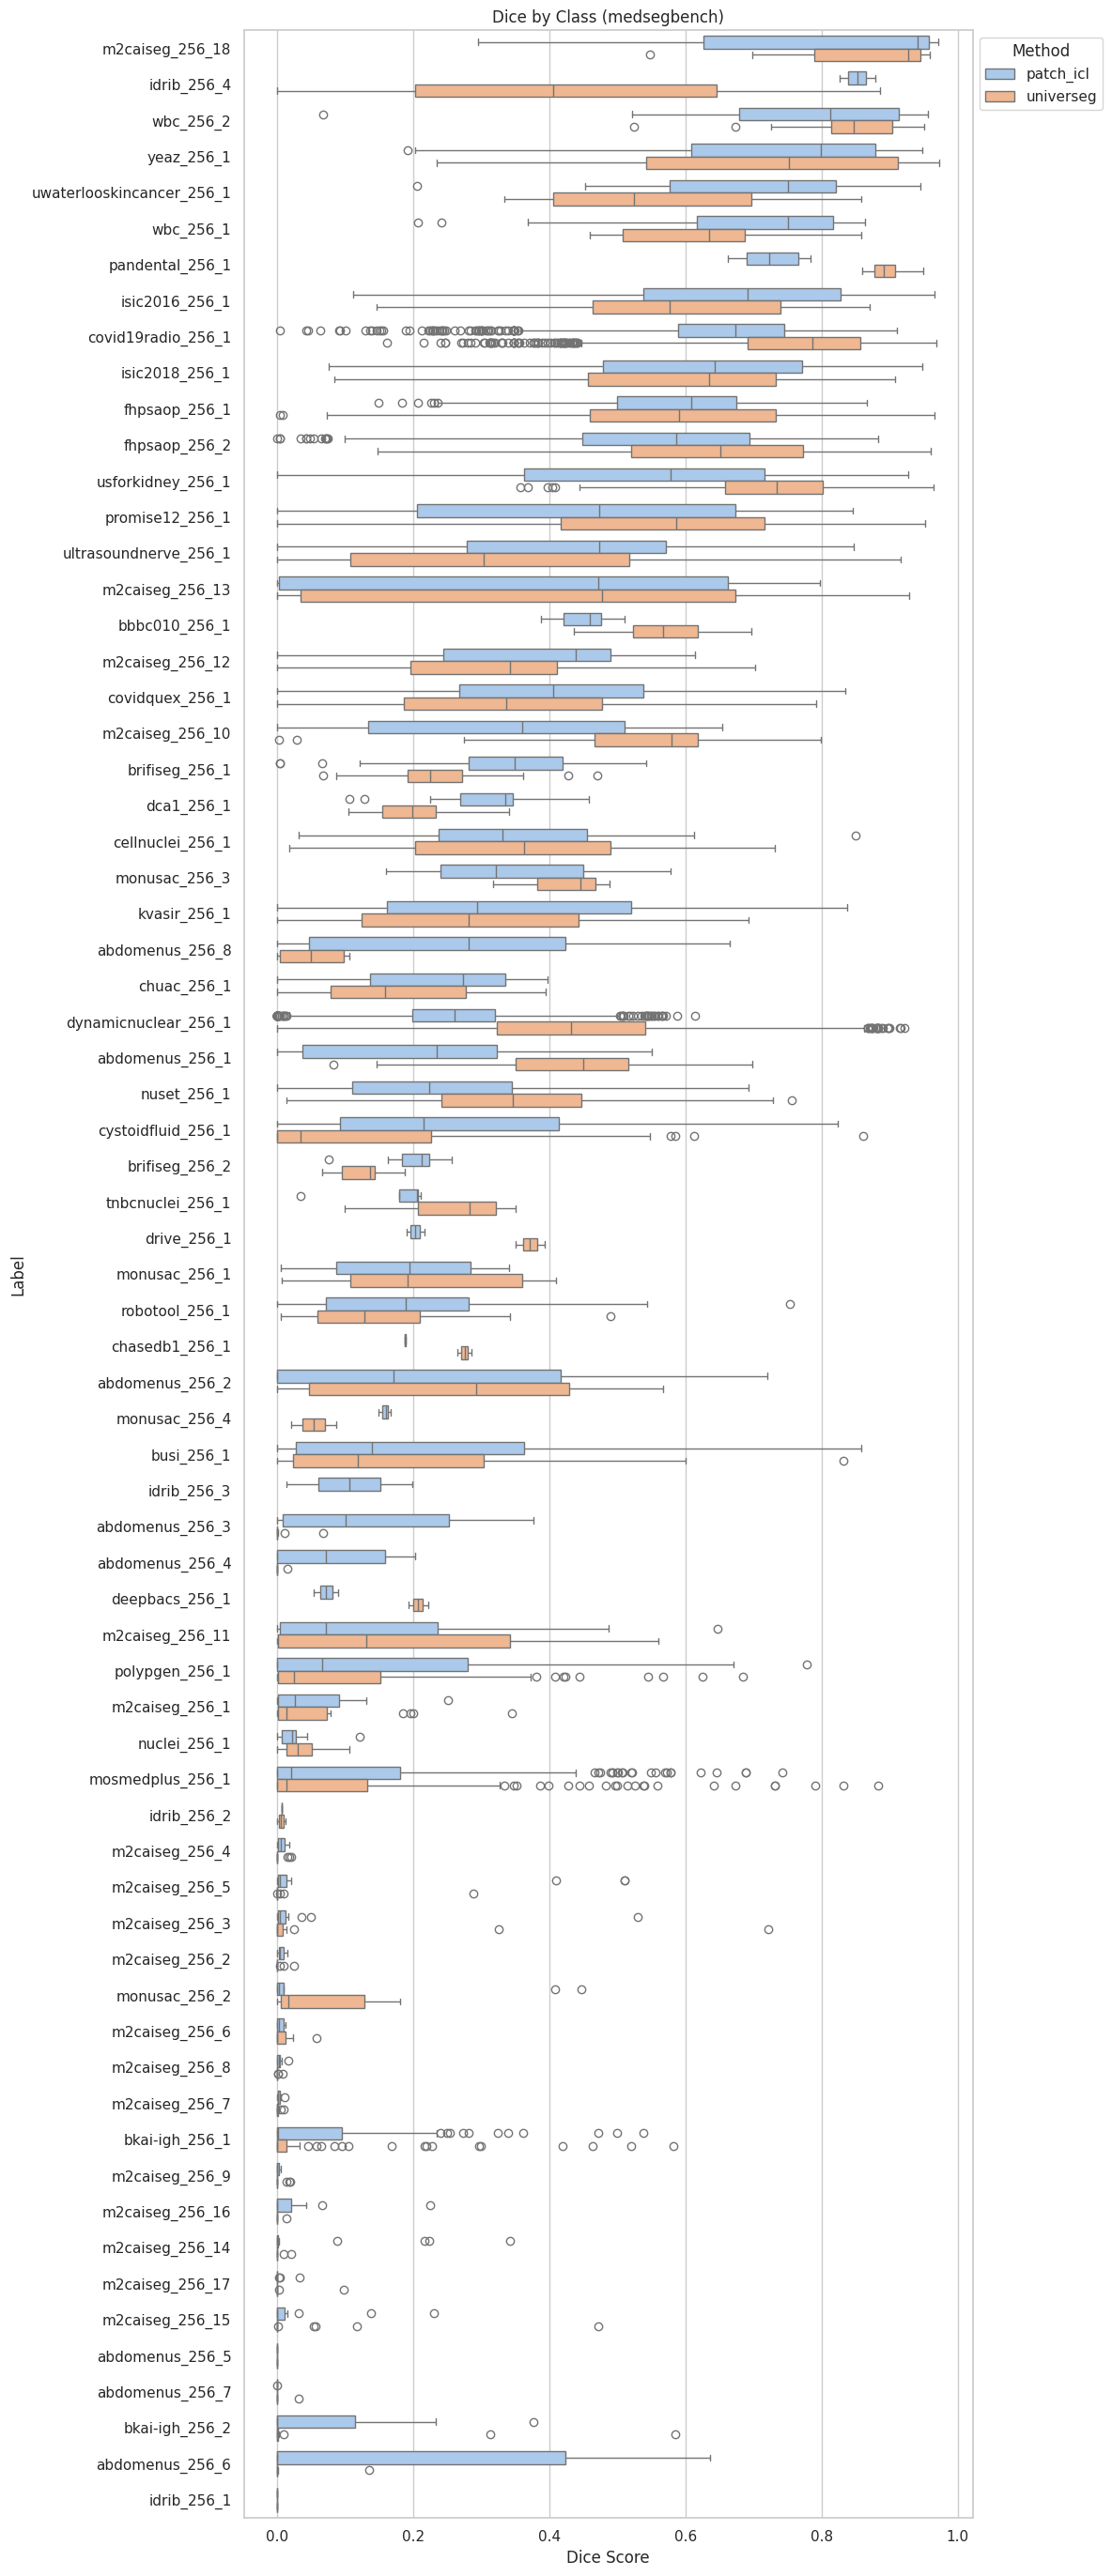


Dice results by label:

Label: m2caiseg_256_18
  Method: patch_icl    Mean: 0.7893  Std: 0.2167  N: 17
  Method: universeg    Mean: 0.8670  Std: 0.1175  N: 16

Label: idrib_256_4
  Method: patch_icl    Mean: 0.8525  Std: 0.0370  N: 2
  Method: universeg    Mean: 0.4304  Std: 0.4432  N: 3

Label: wbc_256_2
  Method: patch_icl    Mean: 0.7579  Std: 0.2130  N: 20
  Method: universeg    Mean: 0.8307  Std: 0.0997  N: 21

Label: yeaz_256_1
  Method: patch_icl    Mean: 0.7376  Std: 0.1735  N: 96
  Method: universeg    Mean: 0.7201  Std: 0.1993  N: 96

Label: uwaterlooskincancer_256_1
  Method: patch_icl    Mean: 0.6938  Std: 0.1885  N: 19
  Method: universeg    Mean: 0.5661  Std: 0.1704  N: 19

Label: wbc_256_1
  Method: patch_icl    Mean: 0.6666  Std: 0.2003  N: 20
  Method: universeg    Mean: 0.6267  Std: 0.1260  N: 19

Label: pandental_256_1
  Method: patch_icl    Mean: 0.7273  Std: 0.0452  N: 11
  Method: universeg    Mean: 0.8957  Std: 0.0253  N: 11

Label: isic2016_256_1
  Method: patc

In [4]:
# Boxplot comparison
sort_order = df_all[df_all['Run'] == 'patch_icl'].groupby('label_id')['dice'].median().sort_values(ascending=False).index
df_all['label_id'] = pd.Categorical(df_all['label_id'], categories=sort_order, ordered=True)

n_classes = df_all['label_id'].nunique()
fig_height = max(8, n_classes * 0.4)

plt.figure(figsize=(12, fig_height))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_all, x="dice", y="label_id", hue="Run", orient="h", palette="pastel", width=0.7)
plt.title(f'Dice by Class ({DATASET})')
plt.xlabel('Dice Score')
plt.ylabel('Label')
plt.legend(title='Method', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Print results by label (mean and std for each method)
print("\nDice results by label:")
summary = df_all.groupby(['label_id', 'Run'])['dice'].agg(['mean', 'std', 'count']).reset_index()
for label in sort_order:
    label_summary = summary[summary['label_id'] == label]
    if label_summary.empty:
        continue
    print(f"\nLabel: {label}")
    for _, row in label_summary.iterrows():
        print(f"  Method: {row['Run']:<12} Mean: {row['mean']:.4f}  Std: {row['std']:.4f}  N: {int(row['count'])}")

In [5]:
# Per-class comparison
label_stats = df_all.groupby(['Run', 'label_id'], observed=False)['dice'].mean().reset_index()
pivot = label_stats.pivot(index='label_id', columns='Run', values='dice')
pivot['diff'] = pivot['patch_icl'] - pivot['universeg']
pivot = pivot.sort_values('diff', ascending=False)

print(f"PatchICL wins: {(pivot['diff'] > 0).sum()}/{len(pivot)} classes")
print(f"Overall avg diff: {pivot['diff'].mean():+.3f}\n")
print("TOP 10 (PatchICL advantage):")
print(pivot.head(10)[['patch_icl', 'universeg', 'diff']].to_string())
print("\nBOTTOM 10 (UniverSeg advantage):")
print(pivot.tail(10)[['patch_icl', 'universeg', 'diff']].to_string())

# Overall statistics
print("=" * 60)
print("OVERALL STATISTICS")
print("=" * 60)
for run_name in ['patch_icl', 'universeg']:
    scores = df_all[df_all['Run'] == run_name]['dice']
    print(f"{run_name:<12}: {scores.mean():.3f} +/- {scores.std():.3f}")

PatchICL wins: 37/69 classes
Overall avg diff: +0.003

TOP 10 (PatchICL advantage):
Run                        patch_icl  universeg      diff
label_id                                                 
idrib_256_4                 0.852519   0.430413  0.422106
abdomenus_256_8             0.277735   0.051536  0.226199
abdomenus_256_6             0.212210   0.019557  0.192653
abdomenus_256_3             0.143137   0.008000  0.135137
cystoidfluid_256_1          0.271722   0.139884  0.131837
uwaterlooskincancer_256_1   0.693769   0.566097  0.127672
brifiseg_256_1              0.341505   0.228476  0.113029
monusac_256_4               0.158786   0.053900  0.104886
ultrasoundnerve_256_1       0.426727   0.321997  0.104730
dca1_256_1                  0.297439   0.202648  0.094791

BOTTOM 10 (UniverSeg advantage):
Run                   patch_icl  universeg      diff
label_id                                            
bbbc010_256_1          0.450525   0.567321 -0.116796
promise12_256_1        0.43

In [11]:
df_all['dataset_name'] = df_all['label_id'].astype(str).str.extract(r'^([a-zA-Z0-9\-]+)_\d+_')[0]

ds_stats = df_all.groupby(['Run', 'dataset_name'])['dice'].agg(['mean', 'std']).reset_index()
ds_pivot = ds_stats.pivot(index='dataset_name', columns='Run', values='mean')
ds_pivot['diff'] = ds_pivot['patch_icl'] - ds_pivot['universeg']
ds_pivot = ds_pivot.sort_values('diff', ascending=False)

print(f"{'Dataset':<30} {'PatchICL':>10} {'UniverSeg':>10} {'Diff':>8}")
print("-" * 62)
for ds, row in ds_pivot.iterrows():
    diff_str = f"{row['diff']:+.3f}" if not pd.isna(row['diff']) else "   N/A"
    p = f"{row['patch_icl']:.3f}" if not pd.isna(row['patch_icl']) else "  N/A"
    u = f"{row['universeg']:.3f}" if not pd.isna(row['universeg']) else "  N/A"
    print(f"{str(ds):<30} {p:>10} {u:>10} {diff_str:>8}")

print(f"\nPatchICL wins: {(ds_pivot['diff'] > 0).sum()}/{ds_pivot['diff'].notna().sum()} datasets")

Dataset                          PatchICL  UniverSeg     Diff
--------------------------------------------------------------
cystoidfluid                        0.272      0.140   +0.132
uwaterlooskincancer                 0.694      0.566   +0.128
brifiseg                            0.328      0.222   +0.106
ultrasoundnerve                     0.427      0.322   +0.105
idrib                               0.321      0.217   +0.103
dca1                                0.297      0.203   +0.095
isic2016                            0.665      0.584   +0.081
polypgen                            0.165      0.100   +0.065
robotool                            0.208      0.144   +0.064
covidquex                           0.401      0.341   +0.060
kvasir                              0.337      0.292   +0.045
isic2018                            0.614      0.574   +0.040
chuac                               0.224      0.185   +0.039
abdomenus                           0.175      0.148   +0.027
mosmedp

In [6]:
# Category/Dataset summary
cat_stats = df_all.groupby(['Run', 'category'], observed=False)['dice'].agg(['mean', 'std']).reset_index()
cat_stats = cat_stats.sort_values(['Run', 'mean'], ascending=[True, False])

category_label = "DATASET" if DATASET == "medsegbench" else "CATEGORY"
print(f"DICE BY {category_label}\n" + "="*60)
for run_name, grp in cat_stats.groupby('Run'):
    print(f"\n--- {run_name} ---")
    for _, row in grp.iterrows():
        print(f"{row['category']:<35} {row['mean']:.3f} +/- {row['std']:.3f}")

# Compare PatchICL vs UniverSeg per category/dataset
cat_pivot = cat_stats.pivot(index='category', columns='Run', values='mean')
cat_pivot['diff'] = cat_pivot['patch_icl'] - cat_pivot['universeg']
cat_pivot = cat_pivot.sort_values('diff', ascending=False)

patch_wins = cat_pivot[cat_pivot['diff'] > 0]
univ_wins = cat_pivot[cat_pivot['diff'] < 0]

print(f"\n" + "="*60)
print(f"PATCHICL vs UNIVERSEG BY {category_label}")
print("="*60)
print(f"\nPatchICL better on {len(patch_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in patch_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['universeg']:.3f} (Δ={row['diff']:+.3f})")

print(f"\nUniverSeg better on {len(univ_wins)}/{len(cat_pivot)} {category_label.lower()}s:")
for cat, row in univ_wins.iterrows():
    print(f"  {cat:<35} {row['patch_icl']:.3f} vs {row['universeg']:.3f} (Δ={row['diff']:+.3f})")

DICE BY DATASET

--- patch_icl ---
X-Ray                               0.727 +/- 0.045
Dermoscopy                          0.643 +/- 0.204
Chest X-Ray                         0.610 +/- 0.174
Microscopy                          0.539 +/- 0.252
Ultrasound                          0.484 +/- 0.241
MRI                                 0.433 +/- 0.270
Nuclei                              0.344 +/- 0.150
Fundus                              0.279 +/- 0.212
OCT                                 0.272 +/- 0.223
Nuclear Cell                        0.254 +/- 0.120
Endoscopy                           0.174 +/- 0.231
CT                                  0.121 +/- 0.178
Pathology                           0.118 +/- 0.146

--- universeg ---
X-Ray                               0.896 +/- 0.025
Chest X-Ray                         0.684 +/- 0.216
Dermoscopy                          0.578 +/- 0.190
MRI                                 0.565 +/- 0.211
Ultrasound                          0.553 +/- 0.261
Microscopy

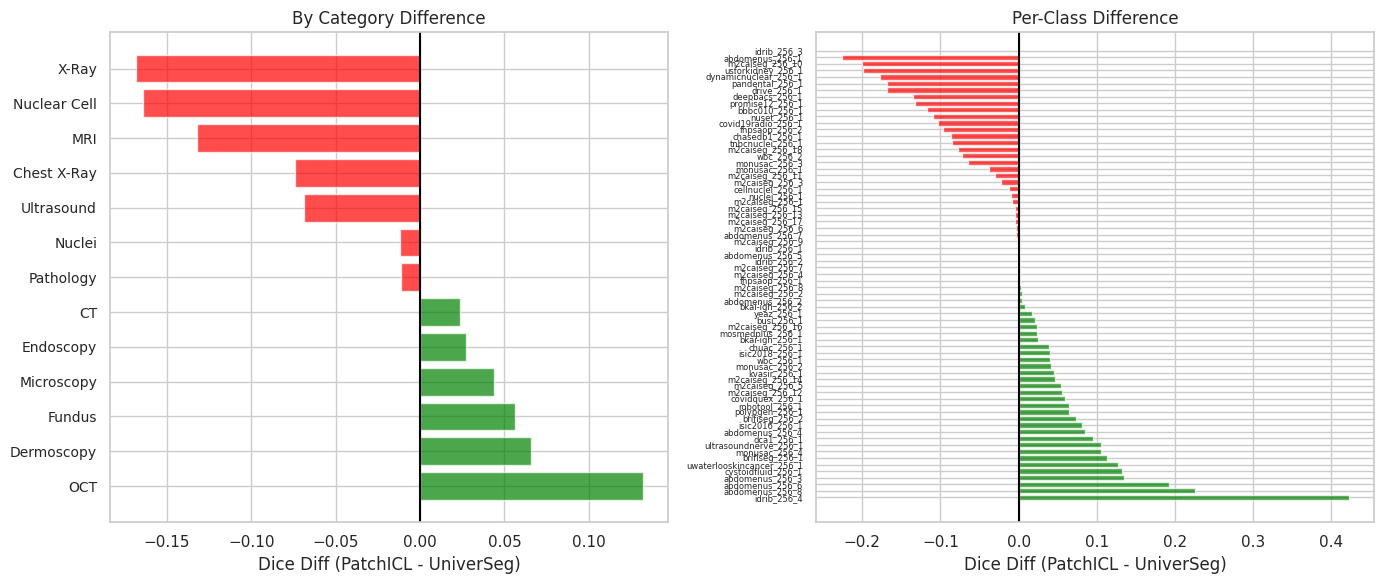

In [7]:
# Summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Category/Dataset diff comparison (same method as per-class)
category_label = "Category"
cat_diff_sorted = cat_pivot['diff'].sort_values(ascending=False)
colors = ['green' if d > 0 else 'red' for d in cat_diff_sorted]
ax = axes[0]
ax.barh(range(len(cat_diff_sorted)), cat_diff_sorted.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(cat_diff_sorted)))
ax.set_yticklabels(cat_diff_sorted.index, fontsize=10)
ax.axvline(x=0, color='black')
ax.set_xlabel('Dice Diff (PatchICL - UniverSeg)')
ax.set_title(f'By {category_label} Difference')

# Per-class diff (always shown)
ax = axes[1]
diff_sorted = pivot['diff'].sort_values(ascending=False)
colors = ['green' if d > 0 else 'red' for d in diff_sorted]
ax.barh(range(len(diff_sorted)), diff_sorted.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(diff_sorted)))
ax.set_yticklabels(diff_sorted.index, fontsize=6)
ax.axvline(x=0, color='black')
ax.set_xlabel('Dice Diff (PatchICL - UniverSeg)')
ax.set_title('Per-Class Difference')

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu, pearsonr, spearmanr

# 6. Category-level statistical tests
print("6. CATEGORY-LEVEL STATISTICAL TESTS")
print("-" * 70)

cat_results = []
for cat in df_all['category'].unique():
    df_p = df_all[(df_all['Run'] == 'patch_icl') & (df_all['category'] == cat)]
    df_u = df_all[(df_all['Run'] == 'universeg') & (df_all['category'] == cat)]
    
    # Paired by case_id and label_id
    idx_p = df_p.set_index(['case_id', 'label_id'])['dice']
    idx_u = df_u.set_index(['case_id', 'label_id'])['dice']
    common = idx_p.index.intersection(idx_u.index)
    
    if len(common) >= 20:
        stat, p = wilcoxon(idx_p.loc[common].values, idx_u.loc[common].values)
        diff = idx_p.loc[common].mean() - idx_u.loc[common].mean()
        cat_results.append({
            'category': cat,
            'n_samples': len(common),
            'patch_icl': idx_p.loc[common].mean(),
            'universeg': idx_u.loc[common].mean(),
            'diff': diff,
            'p_value': p
        })

cat_results_df = pd.DataFrame(cat_results).sort_values('diff', ascending=False)
cat_results_df['p_bonferroni'] = cat_results_df['p_value'] * len(cat_results_df)
cat_results_df['significant'] = cat_results_df['p_bonferroni'] < 0.05

print(f"\n{'Category':<35} {'PatchICL':>9} {'UniverSeg':>10} {'Diff':>8} {'p_adj':>12} {'Sig':>5}")
print("-" * 85)
for _, row in cat_results_df.iterrows():
    sig_mark = "*" if row['significant'] else ""
    print(f"{row['category']:<35} {row['patch_icl']:>9.3f} {row['universeg']:>10.3f} {row['diff']:>+8.3f} {row['p_bonferroni']:>12.2e} {sig_mark:>5}")

6. CATEGORY-LEVEL STATISTICAL TESTS
----------------------------------------------------------------------

Category                             PatchICL  UniverSeg     Diff        p_adj   Sig
-------------------------------------------------------------------------------------
OCT                                     0.272      0.140   +0.132     1.21e-05     *
Dermoscopy                              0.643      0.578   +0.066     5.59e-04     *
Microscopy                              0.540      0.487   +0.053     6.28e-06     *
Endoscopy                               0.193      0.144   +0.049     9.63e-05     *
Fundus                                  0.266      0.224   +0.042     2.73e+00      
CT                                      0.121      0.098   +0.024     3.96e+00      
Pathology                               0.120      0.128   -0.008     2.78e+00      
Nuclei                                  0.344      0.356   -0.012     7.09e+00      
Chest X-Ray                             0

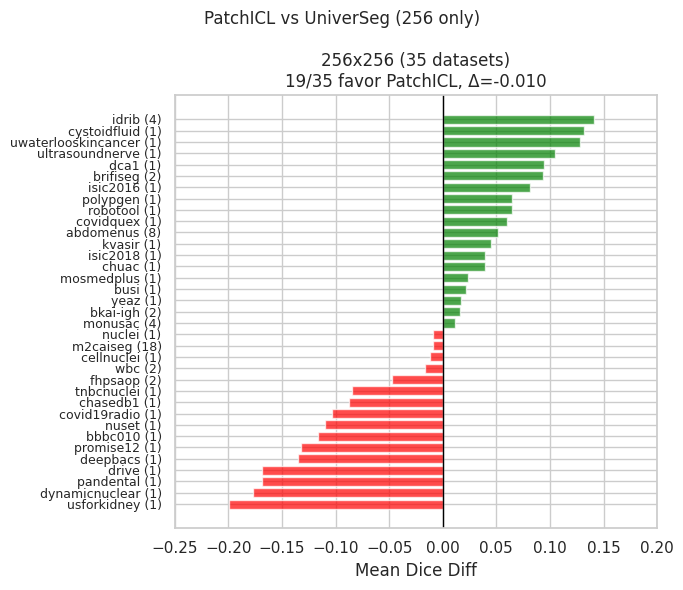

In [9]:
# Summary visualization by resolution, grouped by dataset (256 only)
res = 256
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# In `pivot`, label_id is the index (not a column), so parse metadata from index values.
label_ids = pivot.index.to_series().astype(str)
pivot_plot = pivot.copy()
pivot_plot['dataset'] = label_ids.str.extract(r'^([a-zA-Z0-9\-]+)_\d+_')[0].values
pivot_plot['resolution'] = pd.to_numeric(label_ids.str.extract(r'_([0-9]+)_')[0], errors='coerce')

sub = pivot_plot[pivot_plot['resolution'] == res].copy()

if len(sub) > 0:
    # Group by dataset and drop missing dataset names
    ds_stats = sub.groupby('dataset').agg({
        'diff': 'mean'
    }).dropna()

    ds_stats['n_classes'] = sub.groupby('dataset').size()
    ds_stats = ds_stats.sort_values('diff', ascending=True)

    if len(ds_stats) > 0:
        colors = ['green' if d > 0 else 'red' for d in ds_stats['diff']]
        y_pos = range(len(ds_stats))

        ax.barh(y_pos, ds_stats['diff'].values, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        labels = [f"{ds} ({int(ds_stats.loc[ds, 'n_classes'])})" for ds in ds_stats.index]
        ax.set_yticklabels(labels, fontsize=9)
        ax.axvline(x=0, color='black', linewidth=1)

        n_ds_win = (ds_stats['diff'] > 0).sum()
        mean_diff = ds_stats['diff'].mean()
        ax.set_title(f'{res}x{res} ({len(ds_stats)} datasets)\n{n_ds_win}/{len(ds_stats)} favor PatchICL, Δ={mean_diff:+.3f}')
        ax.set_xlabel('Mean Dice Diff')
        ax.set_xlim(-0.25, 0.2)
    else:
        ax.text(0.5, 0.5, f'No dataset groups for resolution {res}', ha='center', va='center')
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, f'No data for resolution {res}', ha='center', va='center')
    ax.set_axis_off()

plt.suptitle('PatchICL vs UniverSeg (256 only)', fontsize=12)
plt.tight_layout()
plt.show()